# Proyek Klasifikasi Gambar: [Karakter Jujutsu Kaisen Dataset]
- **Nama:** Putu Mahdalika Intan Pratiwi
- **Email:** mahdaalikaputu@gmail.com
- **ID Dicoding:** CACC014D6X0901

## Import Semua Packages/Library yang Digunakan

In [ ]:
import os
import random
import shutil
import pathlib
from pathlib import Path

import pandas as pd
import numpy as np

import cv2
from PIL import Image
from skimage import io
from skimage.transform import rotate, AffineTransform, warp
from skimage.exposure import adjust_gamma
from skimage.util import img_as_ubyte

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from google.colab import files
from tensorflow.keras.preprocessing import image

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# Mencetak versi TensorFlow yang digunakan
print(tf.__version__)

2.19.0


## Data Preparation

### Data Loading

In [ ]:
# Import module yang disediakan google colab untuk kebutuhan upload file
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"putumahdalika","key":"4a1976da64443878614e2a463f9bf69d"}'}

In [ ]:
# Membuat folder untuk konfigurasi kaggle API
!mkdir -p ~/.kaggle

In [ ]:
# Download kaggle dataset and unzip file
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d angelirodriguez/jujutsu-kaisen-character-dataset
!unzip jujutsu-kaisen-character-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/angelirodriguez/jujutsu-kaisen-character-dataset
License(s): MIT
100% 3.43G/3.43G [00:20<00:00, 181MB/s]

Archive:  jujutsu-kaisen-character-dataset.zip
  inflating: clean_jjk_data/train/Aoi Todo/1253.png  
  inflating: clean_jjk_data/train/Aoi Todo/1262.png  
  inflating: clean_jjk_data/train/Aoi Todo/1265.png  
  inflating: clean_jjk_data/train/Aoi Todo/1266.png  
  inflating: clean_jjk_data/train/Aoi Todo/1271.png  
  inflating: clean_jjk_data/train/Aoi Todo/1280.png  
  inflating: clean_jjk_data/train/Aoi Todo/1282.png  
  inflating: clean_jjk_data/train/Aoi Todo/1285.png  
  inflating: clean_jjk_data/train/Aoi Todo/1286.png  
  inflating: clean_jjk_data/train/Aoi Todo/1287.png  
  inflating: clean_jjk_data/train/Aoi Todo/1300.png  
  inflating: clean_jjk_data/train/Aoi Todo/1308.png  
  inflating: clean_jjk_data/train/Aoi Todo/1309.png  
  inflating: clean_jjk_data/train/Aoi Todo/1310.png  
  inflating: clean_jjk_data/train/Aoi Todo/131

**Data preparation**, dataset gambar asli terdiri dari folder train dan folder val yang didalamnya berisikan lagi data berupa folder sesuai nama karakter, total sebanyak 21 folder. Dataset yang digunakan dalam proyek ini hanya terdiri dari 17 kelas karakter dari serial anime Jujutsu Kaisen.

In [ ]:
# Data Preparation
train_dir = "clean_jjk_data/train"
val_dir = "clean_jjk_data/val"
combined_dir = "clean_jjk_data/dataset"

selected_classes = [
"Aoi Todo",
"Junpei Yoshino",
"Kasumi Miwa",
"Kento Nanami",
"Kiyotaka Ijichi",
"Mahito",
"Mai Zenin",
"Maki Zenin",
"Megumi Fushiguro",
"Momo Nishimiya",
"Nobara Kugisaki",
"Noritosho Kamo",
"Panda",
"Satoru Gojo",
"Sukuna",
"Toge Inumaki",
"Yuji Itadori"
]

# Membuat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

for label in selected_classes:

    os.makedirs(os.path.join(combined_dir, label), exist_ok=True)

    # Salin file dan folder dari train
    train_path = os.path.join(train_dir, label)
    if os.path.exists(train_path):
        for file in os.listdir(train_path):
            src = os.path.join(train_path, file)
            dst = os.path.join(combined_dir, label, file)
            shutil.copy(src, dst)

    # Salin file dan folder dari val
    val_path = os.path.join(val_dir, label)
    if os.path.exists(val_path):
        for file in os.listdir(val_path):
            src = os.path.join(val_path, file)
            dst = os.path.join(combined_dir, label, file)
            shutil.copy(src, dst)

print("Dataset berhasil dibuat")

Dataset berhasil dibuat


In [ ]:
# Dataset Checking
# Fungsi untuk cek jumlah citra dan ukuran resolusi
def print_images_resolution(directory):
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)

        if not os.path.isdir(subdir_path):
            continue

        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        total_images += num_images

        folder_sizes = set()

        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            try:
                with Image.open(img_path) as img:
                    folder_sizes.add(img.size)
            except:
                print(f"  (Error membuka file: {img_file})")

        print("  Ukuran unik:")
        for size in folder_sizes:
            print(f"   - {size}")
        print("---------------")

    print(f"\nTotal: {total_images}")

In [ ]:
# Cek jumlah dataset hasil penggabungan
print_images_resolution("clean_jjk_data/dataset/")

Maki Zenin: 178
  Ukuran unik:
   - (1257, 1079)
   - (552, 991)
   - (1454, 1080)
   - (698, 963)
   - (1509, 1080)
   - (796, 1025)
   - (532, 558)
   - (1466, 801)
   - (970, 1079)
   - (1390, 1080)
   - (1445, 1080)
   - (1896, 1080)
   - (1894, 1080)
   - (411, 961)
   - (1788, 1080)
   - (593, 729)
   - (1500, 1079)
   - (1207, 1080)
   - (810, 907)
   - (744, 1053)
   - (1473, 1080)
   - (1900, 1080)
   - (1553, 1079)
   - (501, 795)
   - (626, 881)
   - (620, 810)
   - (928, 1045)
   - (509, 906)
   - (1607, 1080)
   - (1250, 922)
   - (398, 736)
   - (1623, 1079)
   - (348, 488)
   - (923, 1058)
   - (1853, 958)
   - (658, 1077)
   - (1482, 1012)
   - (922, 1080)
   - (1475, 1015)
   - (825, 1074)
   - (1916, 1078)
   - (817, 1079)
   - (831, 1078)
   - (1640, 1079)
   - (828, 1079)
   - (1754, 1080)
   - (664, 867)
   - (1342, 1080)
   - (344, 657)
   - (1310, 978)
   - (1027, 1035)
   - (1441, 1080)
   - (1914, 1080)
   - (377, 489)
   - (1402, 1079)
   - (1853, 1079)
   - (

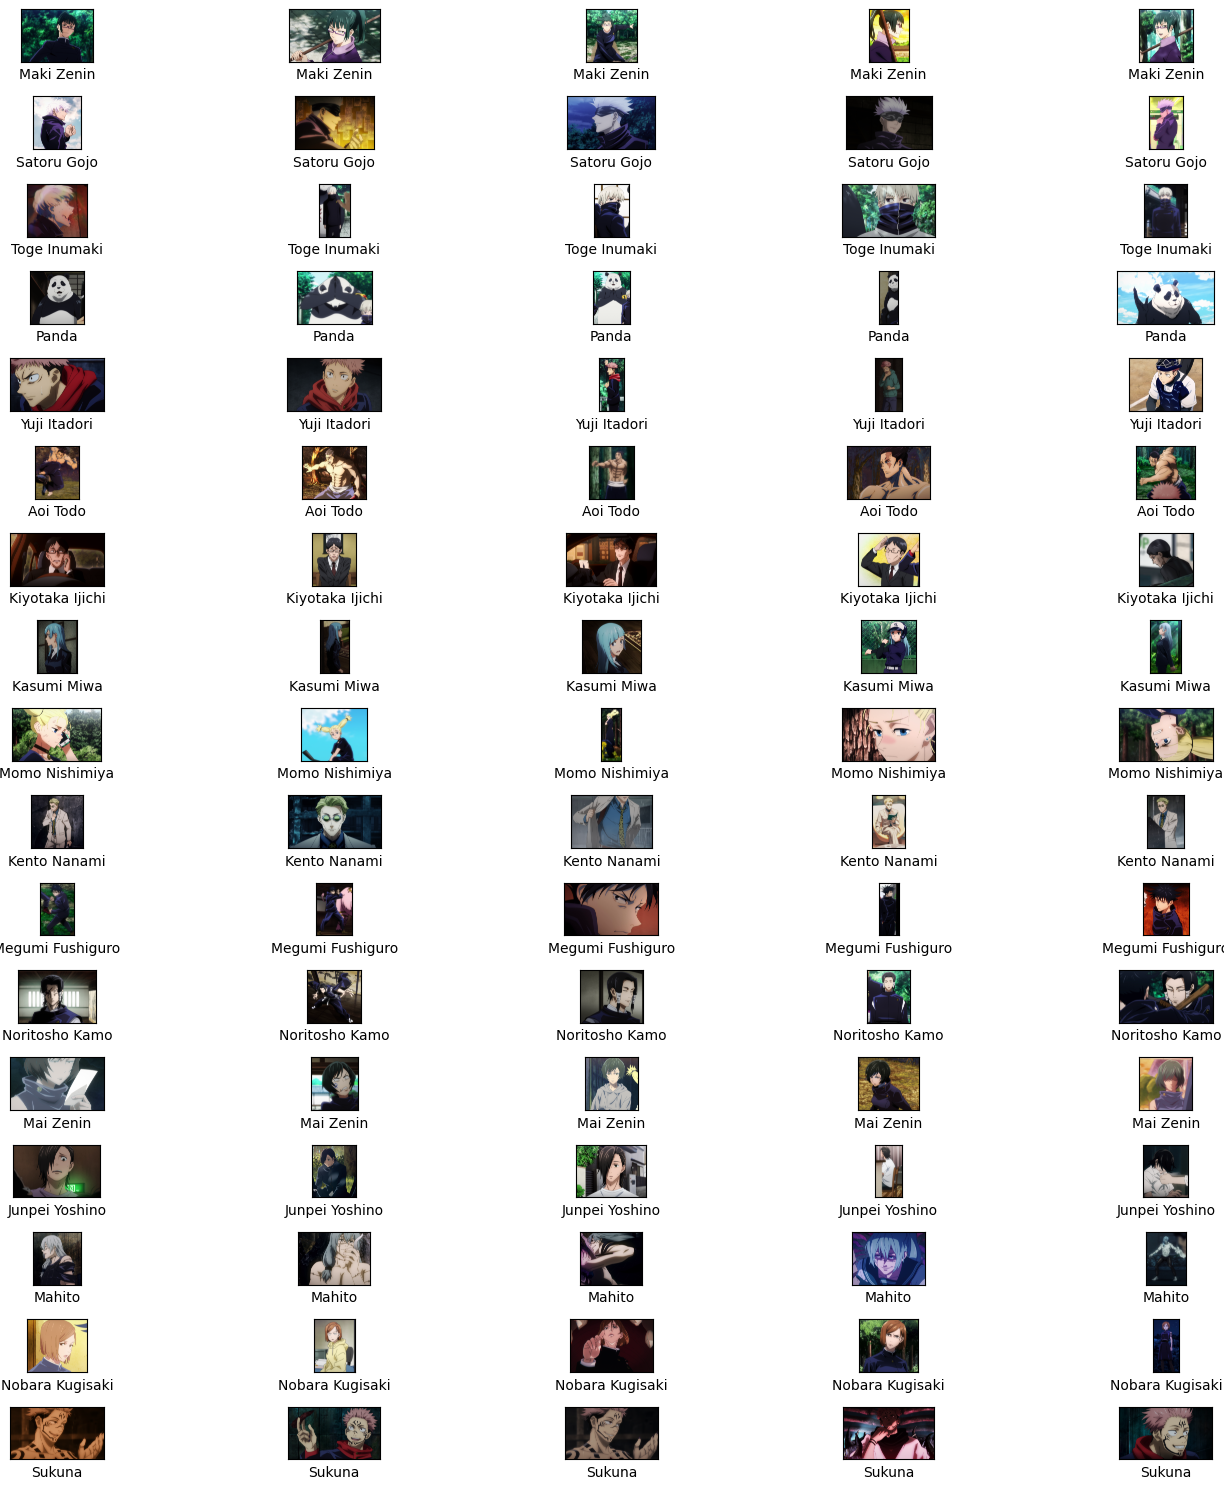

In [ ]:
# Plot Distribusi
# Plot gambar sampel untuk semua kelas
lung_image = {}

# Tentukan path
path = "clean_jjk_data/dataset"
path_sub = os.path.join(path)

# Ambil hanya folder sebagai kelas
class_list = [data for data in os.listdir(path_sub) if os.path.isdir(os.path.join(path_sub, data))]

# Buat dictionary gambar
for i in class_list:
    lung_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap kelas
fig, axs = plt.subplots(len(lung_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(class_list):
    # Pilih minimal antara 5 atau jumlah gambar tersedia
    num_samples = min(5, len(lung_image[class_name]))
    images = np.random.choice(lung_image[class_name], num_samples, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()

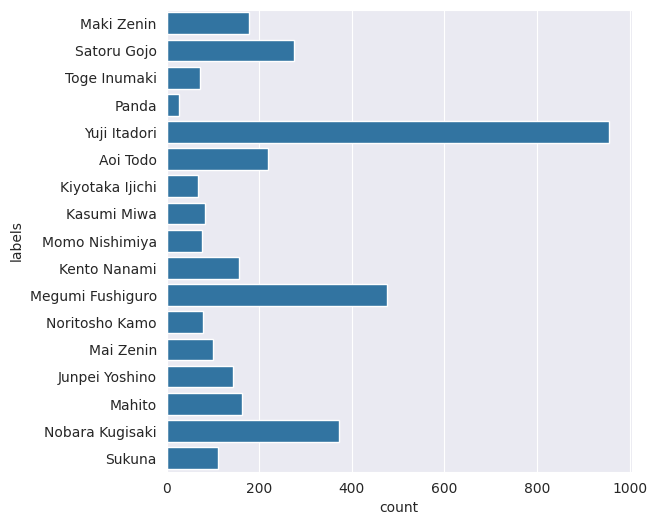

In [ ]:
# Plot distribusi gambar di seluruh kelas
lung_path = "clean_jjk_data/dataset"

# Membuat list berisikan filenames, filepaths, dan labels dari data
file_name = []
labels = []
full_path = []

valid_ext = ('.jpg', '.jpeg', '.png')

# Mengambil data gambar filenames, filepaths, labels dengan looping
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        # Lewati file non-gambar
        if not name.lower().endswith(valid_ext):
            continue

        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

# Plot distribusi
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [ ]:
# Data Resize
input_folder="clean_jjk_data/dataset"
output_folder="clean_jjk_data/normal_resized"

TARGET_SIZE = (224, 224)

# Membuat folder jika belum ada
os.makedirs(output_folder, exist_ok=True)

valid_ext = (".jpg", ".jpeg", ".png")

for class_entry in os.scandir(input_folder):

    if not class_entry.is_dir():
        continue

    class_name = class_entry.name
    input_class_path = class_entry.path

    output_class_path = os.path.join(output_folder, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    for img_entry in os.scandir(input_class_path):

        if not img_entry.name.lower().endswith(valid_ext):
            continue

        img_path = img_entry.path

        try:
            img = cv2.imread(img_path)

            if img is None:
                continue

            img_resized = cv2.resize(
                img,
                TARGET_SIZE,
                interpolation=cv2.INTER_AREA
            )

            save_path = os.path.join(output_class_path, img_entry.name)

            cv2.imwrite(save_path, img_resized)

        except Exception as e:
            print(f"Error membaca {img_entry.name}: {e}")

In [ ]:
# Cek jumlah dataset hasil resized
print_images_resolution("clean_jjk_data/normal_resized")

Maki Zenin: 178
  Ukuran unik:
   - (224, 224)
---------------
Satoru Gojo: 276
  Ukuran unik:
   - (224, 224)
---------------
Toge Inumaki: 72
  Ukuran unik:
   - (224, 224)
---------------
Panda: 28
  Ukuran unik:
   - (224, 224)
---------------
Yuji Itadori: 956
  Ukuran unik:
   - (224, 224)
---------------
Aoi Todo: 218
  Ukuran unik:
   - (224, 224)
---------------
Kiyotaka Ijichi: 69
  Ukuran unik:
   - (224, 224)
---------------
Kasumi Miwa: 82
  Ukuran unik:
   - (224, 224)
---------------
Momo Nishimiya: 77
  Ukuran unik:
   - (224, 224)
---------------
Kento Nanami: 157
  Ukuran unik:
   - (224, 224)
---------------
Megumi Fushiguro: 476
  Ukuran unik:
   - (224, 224)
---------------
Noritosho Kamo: 79
  Ukuran unik:
   - (224, 224)
---------------
Mai Zenin: 100
  Ukuran unik:
   - (224, 224)
---------------
Junpei Yoshino: 143
  Ukuran unik:
   - (224, 224)
---------------
Mahito: 162
  Ukuran unik:
   - (224, 224)
---------------
Nobara Kugisaki: 373
  Ukuran unik:
   - (

**Data augmentation**, dilakukan beberapa transformasi pada gambar untuk meningkatkan variasi data. Beberapa teknik yang digunakan adalah

- Rotasi gambar : Memutar gambar secara acak dalam rentang sudut tertentu
- Brigthness : Untuk mensimulasikan kondisi pencahayaan yang berbeda
- Blur : Untuk memberikan efek kabur pada gambar sehingga model lebih tahan terhadap noise visual
- Shear : Untuk memberikan efek pergeseran atau kemiringan pada gambar
- Horizontal Flip : Untuk membalikkan gambar secara horizontal sehingga gambar dapat dikenali dari arah yang berbeda

In [ ]:
# Data Augmentation
# Fungsi untuk melakukan rotasi
def rotation_image(img):
  sudut = random.uniform(-15, 15)
  rotasi = rotate(img, sudut, mode='edge')
  return img_as_ubyte(rotasi)

# Fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
  gamma = random.uniform(0.8, 1.2)
  bright = adjust_gamma(img, gamma=gamma)
  return img_as_ubyte(bright)

# Fungsi untuk memberikan efek blur pada gambar
def blur_image(img):
  return cv2.GaussianBlur(img, (3,3),0)

# Fungsi untuk efek pergeseran acak pada gambar
def sheared(img):
  shear_value = random.uniform(-0.08, 0.08)
  transform = AffineTransform(shear=shear_value)

  sheared = warp(img, transform, mode="wrap")
  return sheared

# Fungsi untuk flip secara horizontal
def horizontal_flip(img):
  return cv2.flip(img, 1)

In [ ]:
# Membuat variabel transformasi
transformations = { 'rotate': rotation_image,
                    'add brightness' : add_brightness,
                    'blur' : blur_image,
                    'shear image': sheared,
                    'flip' : horizontal_flip
                  }

# Path dataset
images_path = "clean_jjk_data/normal_resized"
augmented_path = "clean_jjk_data/dataset_final"

os.makedirs(augmented_path, exist_ok=True)

# Target jumlah gambar per kelas
TARGET_PER_CLASS = 650

class_counts = {}

# Hitung jumlah gambar per kelas
for class_name in os.listdir(images_path):

    class_path = os.path.join(images_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    class_counts[class_name] = len(images)

print("Target per kelas:", TARGET_PER_CLASS)

# Augmentasi
for class_name, current_count in class_counts.items():

    class_path = os.path.join(images_path, class_name)
    save_class_path = os.path.join(augmented_path, class_name)

    os.makedirs(save_class_path, exist_ok=True)

    images = [
        os.path.join(class_path, img)
        for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    images_to_generate = max(0, TARGET_PER_CLASS - current_count)

    print(f"{class_name} -> tambah {images_to_generate}")

    # Copy gambar asli
    for img in images:
        filename = os.path.basename(img)
        cv2.imwrite(
            os.path.join(save_class_path, filename),
            cv2.imread(img)
        )

    # Generate augmentasi
    for i in range(images_to_generate):

        image_path = random.choice(images)

        try:
            img = io.imread(image_path)

            # hanya 1–2 transformasi
            transform_count = random.randint(1, 2)

            for _ in range(transform_count):
                key = random.choice(list(transformations))
                img = transformations[key](img)

            save_path = os.path.join(
                save_class_path,
                f"aug_{i}.jpg"
            )

            cv2.imwrite(save_path, img_as_ubyte(img))

        except Exception as e:
            print("skip:", image_path, e)

Target per kelas: 650
Maki Zenin -> tambah 472
Satoru Gojo -> tambah 374
Toge Inumaki -> tambah 578
Panda -> tambah 622
Yuji Itadori -> tambah 0
Aoi Todo -> tambah 432
Kiyotaka Ijichi -> tambah 581
Kasumi Miwa -> tambah 568
Momo Nishimiya -> tambah 573
Kento Nanami -> tambah 493
Megumi Fushiguro -> tambah 174
Noritosho Kamo -> tambah 571
Mai Zenin -> tambah 550
Junpei Yoshino -> tambah 507
Mahito -> tambah 488
Nobara Kugisaki -> tambah 277
Sukuna -> tambah 539


In [ ]:
# Cek total dataset final sebelum dilakukan splitting data
print_images_resolution("clean_jjk_data/dataset_final")

Maki Zenin: 650
  Ukuran unik:
   - (224, 224)
---------------
Satoru Gojo: 650
  Ukuran unik:
   - (224, 224)
---------------
Toge Inumaki: 650
  Ukuran unik:
   - (224, 224)
---------------
Panda: 650
  Ukuran unik:
   - (224, 224)
---------------
Yuji Itadori: 956
  Ukuran unik:
   - (224, 224)
---------------
Aoi Todo: 650
  Ukuran unik:
   - (224, 224)
---------------
Kiyotaka Ijichi: 650
  Ukuran unik:
   - (224, 224)
---------------
Kasumi Miwa: 650
  Ukuran unik:
   - (224, 224)
---------------
Momo Nishimiya: 650
  Ukuran unik:
   - (224, 224)
---------------
Kento Nanami: 650
  Ukuran unik:
   - (224, 224)
---------------
Megumi Fushiguro: 650
  Ukuran unik:
   - (224, 224)
---------------
Noritosho Kamo: 650
  Ukuran unik:
   - (224, 224)
---------------
Mai Zenin: 650
  Ukuran unik:
   - (224, 224)
---------------
Junpei Yoshino: 650
  Ukuran unik:
   - (224, 224)
---------------
Mahito: 650
  Ukuran unik:
   - (224, 224)
---------------
Nobara Kugisaki: 650
  Ukuran unik:


### Data Preprocessing

#### Split Dataset

In [ ]:
# Memanggil variabel mypath yang menampung folder dataset gambar
mypath= 'clean_jjk_data/dataset_final'

file_name = []
labels = []
full_path = []

valid_ext = ('.jpg', '.jpeg', '.png')

for path, subdirs, files in os.walk(mypath):
    for name in files:

        # Abaikan file selain gambar
        if not name.lower().endswith(valid_ext):
            continue

        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

# Memasukan variabel yang sudah dikumpulkan pada looping menjadi sebuah dataframe
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

# Melihat jumlah data gambar
df.groupby(['labels']).size()

,0
labels,
Aoi Todo,650
Junpei Yoshino,650
Kasumi Miwa,650
Kento Nanami,650
Kiyotaka Ijichi,650
Mahito,650
Mai Zenin,650
Maki Zenin,650
Megumi Fushiguro,650


In [ ]:
# Split dataset awal 90% data train dan 10% data test
train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["labels"],
    random_state=42
)

# Print hasil untuk melihat panjang size data train dan test
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 10220
Test size: 1136


In [ ]:
# Split validation 10% dari data train
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["labels"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 9198
Validation: 1022
Test: 1136


## Modelling

In [ ]:
# Generator dataset
datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="labels",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="labels",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator = datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="labels",
    target_size=(224,224),
    batch_size=1,
    class_mode="categorical",
    shuffle=False
)

print(train_generator.class_indices)

Found 9198 validated image filenames belonging to 17 classes.
Found 1022 validated image filenames belonging to 17 classes.
Found 1136 validated image filenames belonging to 17 classes.
{'Aoi Todo': 0, 'Junpei Yoshino': 1, 'Kasumi Miwa': 2, 'Kento Nanami': 3, 'Kiyotaka Ijichi': 4, 'Mahito': 5, 'Mai Zenin': 6, 'Maki Zenin': 7, 'Megumi Fushiguro': 8, 'Momo Nishimiya': 9, 'Nobara Kugisaki': 10, 'Noritosho Kamo': 11, 'Panda': 12, 'Satoru Gojo': 13, 'Sukuna': 14, 'Toge Inumaki': 15, 'Yuji Itadori': 16}


**Penggunaan model CNN (Convolutional Neural Network)**

Model dibangun menggunakan beberapa lapisan convolutional yang berfungsi untuk mengekstraksi fitur penting dari citra, dengan BatchNormalization untuk menstabilkan proses pelatihan dan Maxpooling untuk mengurangi dimensi fitur. Digunakan GlobalAveragePooling2D untuk merangkum fitur, serta Dropout untuk mengurangi risiko overfitting selama training model.


In [ ]:
tf.keras.backend.clear_session()

# Inisialisasi model Sequential
model_cnn = Sequential()

# Input layer with Fully Connected Layer
# 1. Convolutional Layer, Batch Normalization, dan MaxPooling
model_cnn.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224,224,3)))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPool2D((2,2)))

# 2. Convolutional Layer, Batch Normalization, dan MaxPooling
model_cnn.add(Conv2D(64, (3,3),padding='same', activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPool2D((2,2)))

# 3. Convolutional Layer, Batch Normalization, dan MaxPooling
model_cnn.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPool2D((2,2)))

# GlobalAverage layer untuk mengubah fitur
model_cnn.add(GlobalAveragePooling2D())

# Dense Layer pertama
model_cnn.add(Dense(128, activation = 'relu'))
# Dropout pertama untuk mengurangi overfitting
model_cnn.add(Dropout(0.4))
# Dense Layer kedua
model_cnn.add(Dense(64, activation = 'relu'))
# Dropout kedua
model_cnn.add(Dropout(0.3))

# Final Dense layer
model_cnn.add(Dense(17, activation='softmax'))

# Compile Model
model_cnn.compile(optimizer=tf.keras.optimizers.RMSprop(),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Tampilkan arsitektur model
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,017 (468.82 KB)

 Trainable params: 119,569 (467.07 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Fungsi untuk memantau serta mengatur pelatihan
callbacks_cnn = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='model_cnn.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
# Fungsi perhitungan class weight
def get_class_weights(generator):
  # Ambil label kelas dari generator
  train_labels = generator.classes

  # Ambil daftar kelas unik
  classes = np.unique(train_labels)

  # Hitung class weight
  class_weights_arr = compute_class_weight(
      class_weight='balanced',
      classes=classes,
      y=train_labels
  )

  # Convert ke dictionary
  class_weights = {i: w for i, w in enumerate(class_weights_arr)}

  return class_weights

In [ ]:
class_weights = get_class_weights(train_generator)

# Training model
history_cnn = model_cnn.fit(train_generator,
                    epochs=30,
                    batch_size=64,
                    validation_data=val_generator,
                    class_weight = class_weights,
                    callbacks=callbacks_cnn)

Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.1439 - loss: 2.7002 - val_accuracy: 0.0665 - val_loss: 3.0282 - learning_rate: 0.0010
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.2143 - loss: 2.4863 - val_accuracy: 0.1859 - val_loss: 2.5126 - learning_rate: 0.0010
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.2889 - loss: 2.2658 - val_accuracy: 0.3258 - val_loss: 2.1898 - learning_rate: 0.0010
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.3420 - loss: 2.0940 - val_accuracy: 0.4295 - val_loss: 1.9230 - learning_rate: 0.0010
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.3970 - loss: 1.9293 - val_accuracy: 0.2779 - val_loss: 2.2913 - learning_rate: 0.0010
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.4487 - loss: 1.7533 - val_accuracy: 0.4726 - val_loss: 1.6105 - learning_rate: 0.0010
Epoch 7/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.5015 - 

**Eksperimen Lanjutan dengan Transfer Learning (VGG16)**

VGG (Visual Geometry Group)
Model ini dipilih karena VGG adalah arsitektur yang relatif sederhana, tetapi sangat efektif dalam pengenalan gambar. Model VGG telah dilatih dalam dataset ImageNet yang besar dan memiliki kemampuan baik untuk mengenali berbagai objek pada gambar.

In [ ]:
tf.keras.backend.clear_session()

image_size = 224

# Load model VGG16
vgg_conv = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size, image_size, 3)
)

# Freeze sebagian besar layer
for layer in vgg_conv.layers[:-6]:
    layer.trainable = False

# Build model
model_vgg = models.Sequential()

model_vgg.add(vgg_conv)

# Feature aggregation
model_vgg.add(layers.GlobalAveragePooling2D())

model_vgg.add(layers.BatchNormalization())

model_vgg.add(layers.Dense(512, activation='relu'))
model_vgg.add(layers.Dropout(0.5))

model_vgg.add(layers.Dense(256, activation='relu'))
model_vgg.add(layers.Dropout(0.4))

model_vgg.add(layers.Dense(17, activation='softmax'))

# Compile
model_vgg.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy','top_k_categorical_accuracy']
)

model_vgg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,115,089 (57.66 MB)

 Trainable params: 9,838,609 (37.53 MB)

 Non-trainable params: 5,276,480 (20.13 MB)

In [ ]:
# Fungsi untuk memantau serta mengatur pelatihan
callbacks_vgg = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='model_vgg.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
class_weights = get_class_weights(train_generator)

# Training model
history_vgg = model_vgg.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks_vgg
)

Epoch 1/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 135s 370ms/step - accuracy: 0.2472 - loss: 2.4137 - top_k_categorical_accuracy: 0.6067 - val_accuracy: 0.4892 - val_loss: 1.7365 - val_top_k_categorical_accuracy: 0.8611 - learning_rate: 1.0000e-04
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 75s 260ms/step - accuracy: 0.7819 - loss: 0.7623 - top_k_categorical_accuracy: 0.9631 - val_accuracy: 0.7701 - val_loss: 0.7945 - val_top_k_categorical_accuracy: 0.9569 - learning_rate: 1.0000e-04
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 75s 259ms/step - accuracy: 0.9379 - loss: 0.2261 - top_k_categorical_accuracy: 0.9936 - val_accuracy: 0.9344 - val_loss: 0.2248 - val_top_k_categorical_accuracy: 0.9961 - learning_rate: 1.0000e-04
Epoch 4/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 75s 259ms/step - accuracy: 0.9729 - loss: 0.1025 - top_k_categorical_accuracy: 0.9982 - val_accuracy: 0.9560 - val_loss: 0.1343 - val_top_k_categorical_accuracy: 0.9990 - learning_rate: 1.0000e-04
Epoch 5/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 75s 259ms/s

## Evaluasi dan Visualisasi

In [ ]:
def evaluate_model(history, model, test_generator, model_name="Model"):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    # Accuracy Plot
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, 'r')
    plt.plot(epochs, val_acc, 'b')
    plt.title(f'{model_name} - Training and Validation Accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()

    # Loss Plot
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, 'r')
    plt.plot(epochs, val_loss, 'b')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.title(f'{model_name} - Training and Validation Loss')
    plt.show()

    # Prediction
    test_generator.reset()

    preds = model.predict(test_generator, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    class_names = list(test_generator.class_indices.keys())

    # Confusion Matrix
    cm = confusion_matrix(test_generator.classes, pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    # Classification Report
    print(f"\nClassification Report - {model_name}\n")

    print(classification_report(
        test_generator.classes,
        pred_classes,
        target_names=class_names,
        digits=4
    ))

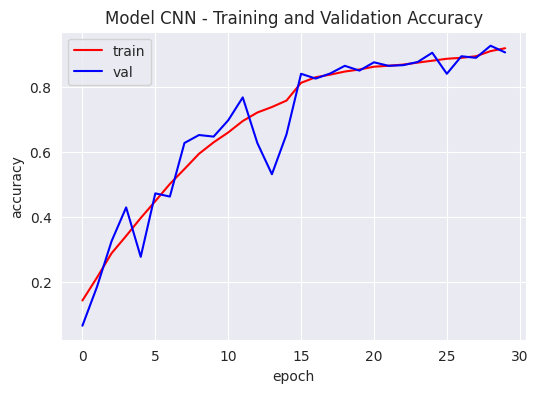

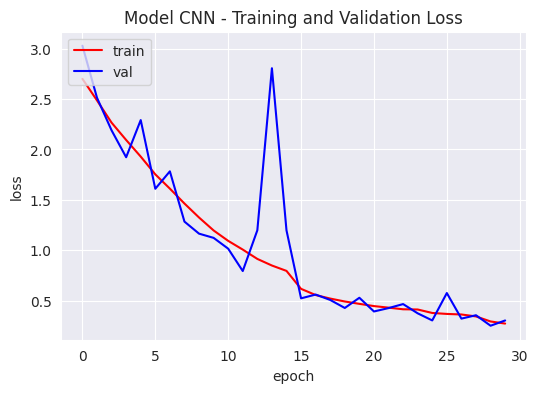

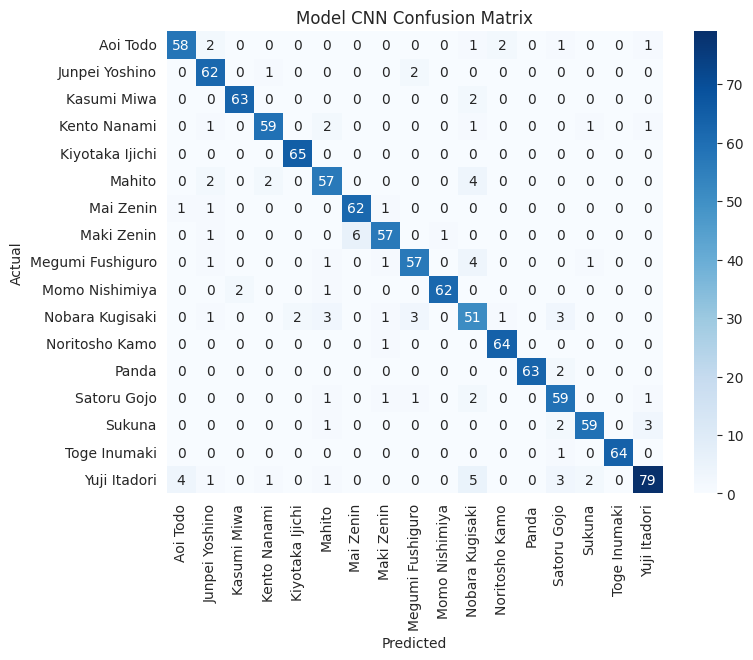


Classification Report - Model CNN

                  precision    recall  f1-score   support

        Aoi Todo     0.9206    0.8923    0.9062        65
  Junpei Yoshino     0.8611    0.9538    0.9051        65
     Kasumi Miwa     0.9692    0.9692    0.9692        65
    Kento Nanami     0.9365    0.9077    0.9219        65
 Kiyotaka Ijichi     0.9701    1.0000    0.9848        65
          Mahito     0.8507    0.8769    0.8636        65
       Mai Zenin     0.9118    0.9538    0.9323        65
      Maki Zenin     0.9194    0.8769    0.8976        65
Megumi Fushiguro     0.9048    0.8769    0.8906        65
  Momo Nishimiya     0.9841    0.9538    0.9688        65
 Nobara Kugisaki     0.7286    0.7846    0.7556        65
  Noritosho Kamo     0.9552    0.9846    0.9697        65
           Panda     1.0000    0.9692    0.9844        65
     Satoru Gojo     0.8310    0.9077    0.8676        65
          Sukuna     0.9365    0.9077    0.9219        65
    Toge Inumaki     1.0000    0.98

In [ ]:
# Evaluasi hasil model CNN
evaluate_model(history_cnn, model_cnn, test_generator, "Model CNN")

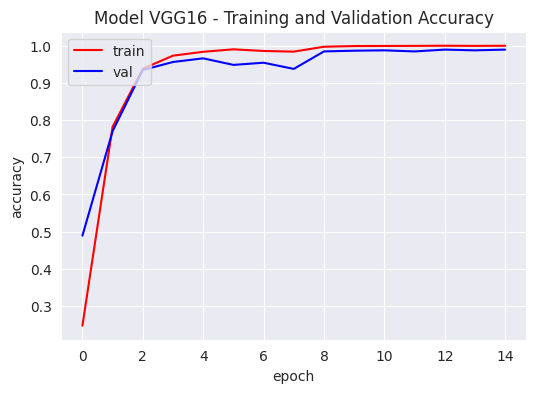

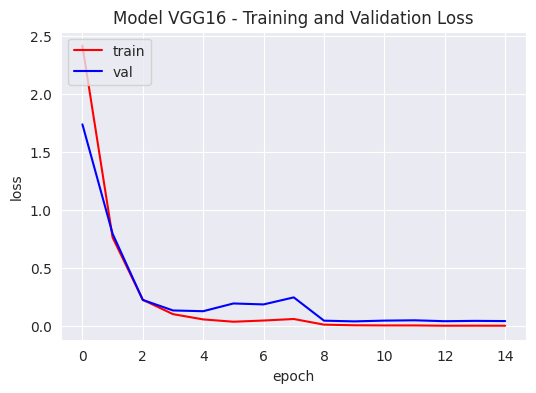

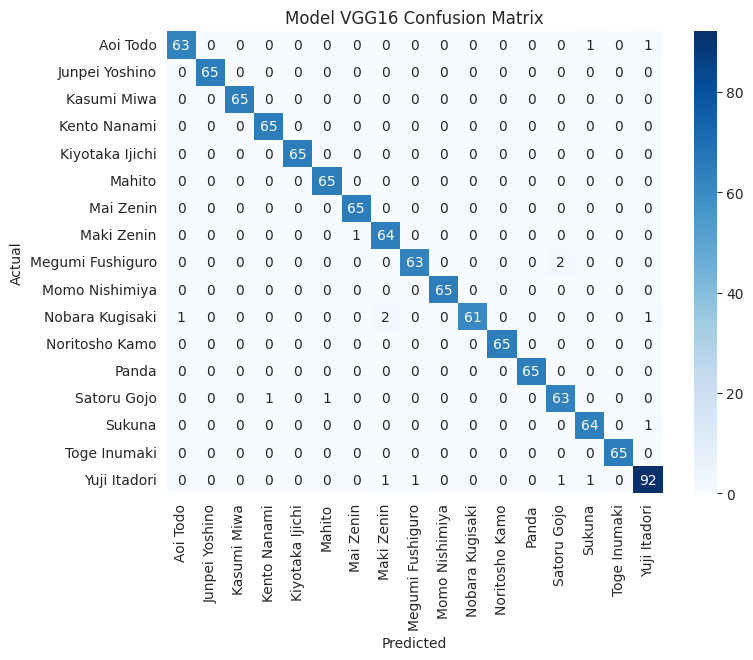


Classification Report - Model VGG16

                  precision    recall  f1-score   support

        Aoi Todo     0.9844    0.9692    0.9767        65
  Junpei Yoshino     1.0000    1.0000    1.0000        65
     Kasumi Miwa     1.0000    1.0000    1.0000        65
    Kento Nanami     0.9848    1.0000    0.9924        65
 Kiyotaka Ijichi     1.0000    1.0000    1.0000        65
          Mahito     0.9848    1.0000    0.9924        65
       Mai Zenin     0.9848    1.0000    0.9924        65
      Maki Zenin     0.9552    0.9846    0.9697        65
Megumi Fushiguro     0.9844    0.9692    0.9767        65
  Momo Nishimiya     1.0000    1.0000    1.0000        65
 Nobara Kugisaki     1.0000    0.9385    0.9683        65
  Noritosho Kamo     1.0000    1.0000    1.0000        65
           Panda     1.0000    1.0000    1.0000        65
     Satoru Gojo     0.9545    0.9692    0.9618        65
          Sukuna     0.9697    0.9846    0.9771        65
    Toge Inumaki     1.0000    1.

In [ ]:
# Evaluasi hasil model VGG16
evaluate_model(history_vgg, model_vgg, test_generator, "Model VGG16")

## Konversi Model

In [ ]:
# Format SavedModel
model = tf.keras.models.load_model("model_vgg.keras")
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  138186815054544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815053968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815056080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815053584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815055504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815056272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815054736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815056464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815056848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815053776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138186815057232: 

In [ ]:
# Format TensorFlow.js
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    /content/saved_model/ \
    /content/modeltfjs

2026-03-17 05:07:36.519697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773724056.540323   41770 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773724056.547131   41770 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773724056.563097   41770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773724056.563119   41770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773724056.563123   41770 computation_placer.cc:177] computation placer alr

In [ ]:
# Format TFLite
os.makedirs("tflite", exist_ok=True)

saved_model_dir = "saved_model"

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('tflite/model.tflite')
tflite_model_file.write_bytes(tflite_model)

# Buat label.txt dalam folder tflite
labels = [
    "Aoi Todo",
    "Junpei Yoshino",
    "Kasumi Miwa",
    "Kento Nanami",
    "Kiyotaka Ijichi",
    "Mahito",
    "Mai Zenin",
    "Maki Zenin",
    "Megumi Fushiguro",
    "Momo Nishimiya",
    "Nobara Kugisaki",
    "Noritosho Kamo",
    "Panda",
    "Satoru Gojo",
    "Sukuna",
    "Toge Inumaki",
    "Yuji Itadori"
]

label_path = pathlib.Path("tflite/label.txt")
label_path.write_text("\n".join(labels))

206

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r modeltfjs /content/drive/MyDrive/
!cp -r saved_model /content/drive/MyDrive/
!cp -r tflite /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Inference (Optional)

Saving images (1).webp to images (1).webp


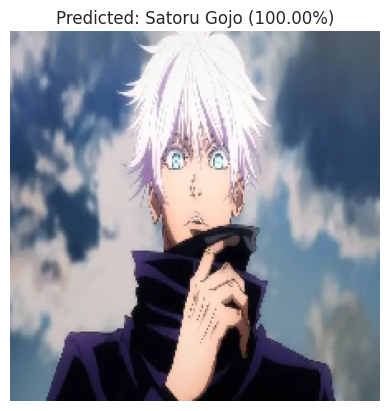

In [ ]:
from google.colab import files

# Inference sederhana menggunakan model VGG16 yang sudah disimpan ke format saved model
# Load saved model
loaded_model = tf.saved_model.load("saved_model/")
infer = loaded_model.signatures["serving_default"]

# Upload gambar
uploaded = files.upload()

# Ambil label kelas
class_indices = train_generator.class_indices
classes = list(class_indices.keys())

# Ambil nama input dari model
input_name = list(infer.structured_input_signature[1].keys())[0]

for fn in uploaded.keys():

    # Load image
    test_img = image.load_img(fn, target_size=(224,224), color_mode='rgb')

    # Preprocessing
    pp_test_img = image.img_to_array(test_img)
    pp_test_img = pp_test_img / 255.0
    pp_test_img = np.expand_dims(pp_test_img, axis=0)

    input_tensor = tf.constant(pp_test_img, dtype=tf.float32)

    # Inference
    output = infer(**{input_name: input_tensor})
    preds = list(output.values())[0].numpy()

    predicted_index = np.argmax(preds)
    confidence = preds[0][predicted_index]

    # Visualisasi
    plt.imshow(test_img)
    plt.title(f"Predicted: {classes[predicted_index]} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

# **Hasil Inference**

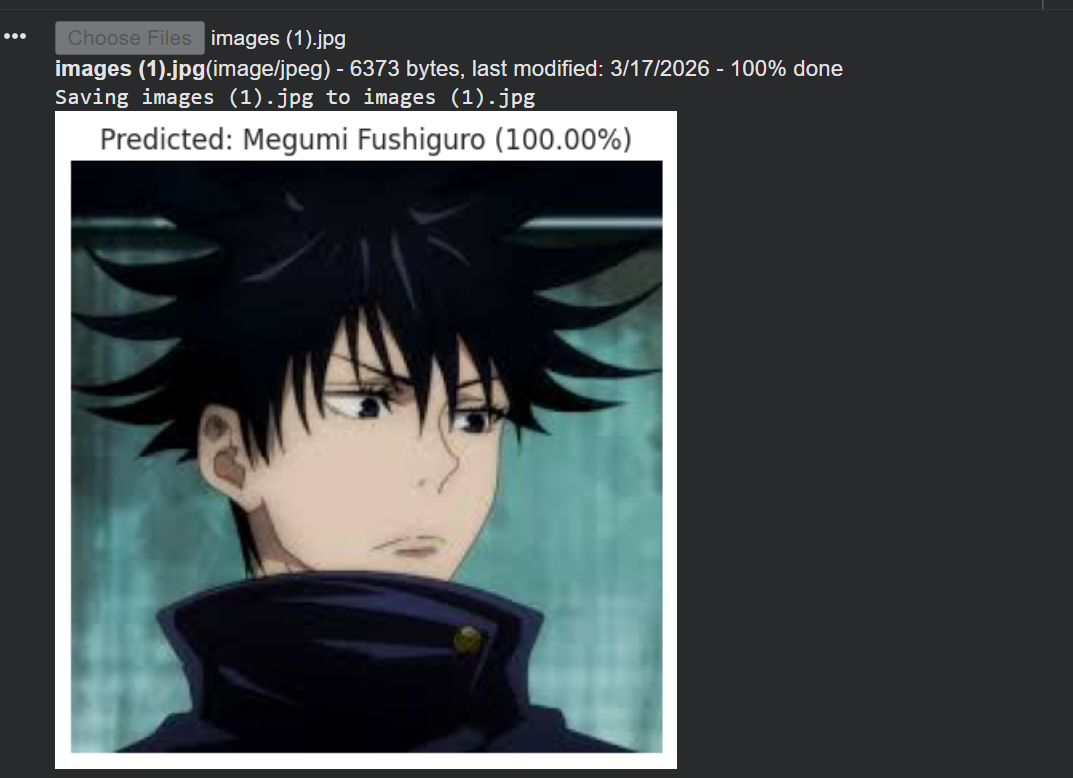

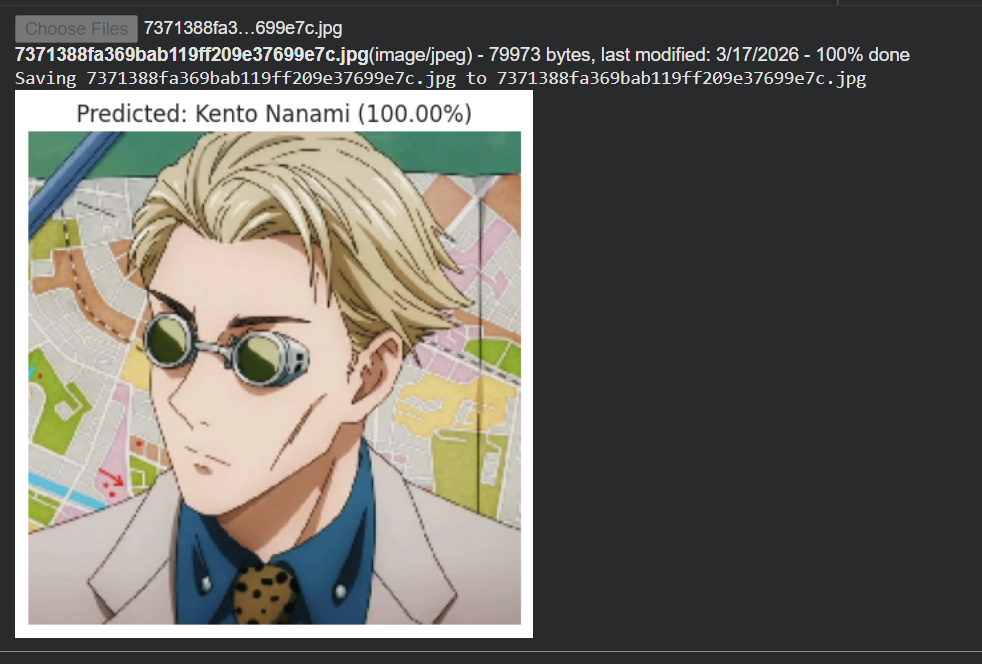